## Exploratory Data Analysis: Defining a Stock-Out Proxy

The Rossmann Store Sales dataset doesn't include an explicit "stock level" field, so a proxy
signal was needed to represent stock-out events.

**Initial approach:** flag days where a store was open (`Open = 1`) but recorded zero sales.
This turned out to be far too rare — only 54 rows out of over 1 million — making it unusable
as a training signal for a predictive model.

**Revised approach:** instead of looking for exactly zero sales, each day's sales were compared
to that store's own typical average (`SalesRatio = Sales / store's average Sales`). Days where
sales dropped below 30% of a store's normal average (while still open) were flagged as
`LikelyStockout` — a more realistic signal for "something went wrong," such as a stock-out,
without relying on an all-or-nothing zero-sales event. This produced 1,232 flagged days.

**Forward-looking target:** since the goal is to *predict* stock-outs before they happen (not
just detect them after the fact), each row was labeled `StockoutNext7Days = 1` if a
`LikelyStockout` event occurred at any point in the following 7 days for that store. This
produced 8,091 positive rows out of ~1.02 million (~0.8%) — a realistic, imbalanced
classification target similar in scale to common real-world prediction problems like fraud
or churn detection.

This `StockoutNext7Days` column is the target variable used for modeling in the next phase.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
df = pd.read_csv('../data/processed/train_store_merged.csv', dtype={'StateHoliday': str})
df['Date'] = pd.to_datetime(df['Date']) 
df.head() 

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,0.0,0.0,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,0.0,0.0,NaN


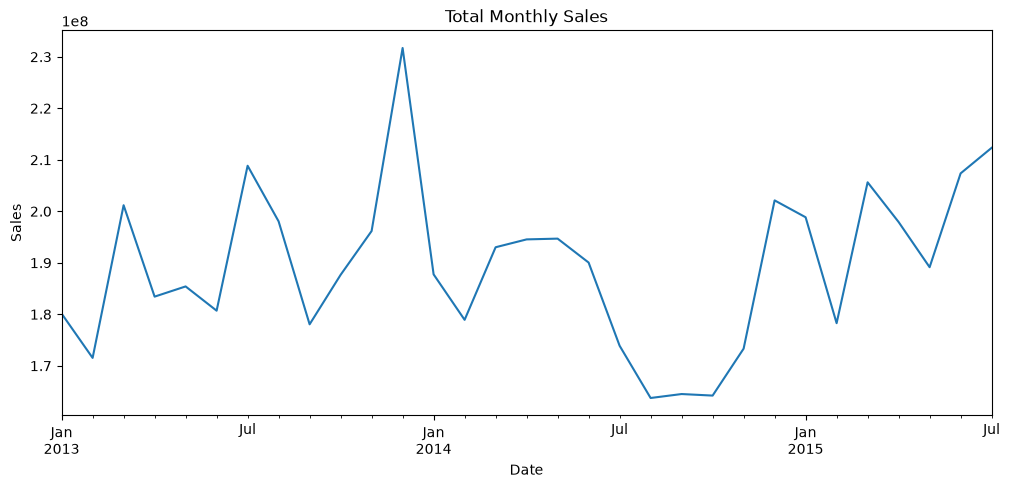

In [3]:
df.groupby(df['Date'].dt.to_period('M'))['Sales'].sum().plot(figsize=(12,5), title='Total Monthly Sales')
plt.ylabel('Sales') 
plt.show()

In [5]:
closed_days = df[df['Open'] == 0] 
print(f"Closed-store rows: {len(closed_days)} ({len(closed_days)/len(df)*100:.1f}% of all rows)")

Closed-store rows: 172817 (17.0% of all rows)


In [9]:
open_zero_sales = df[(df['Open'] == 1) & (df['Sales'] == 0)]
print(f"Open but zero sales: {len(open_zero_sales)} rows") 
open_zero_sales. head()

Open but zero sales: 54 rows


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
86825,971,5,2015-05-15,0,0,1,0,0,1,c,a,1140.0,5.0,2011.0,1,14.0,2012.0,"Mar,Jun,Sept,Dec"
142278,674,4,2015-03-26,0,0,1,0,0,0,a,a,2640.0,12.0,2005.0,1,31.0,2013.0,"Feb,May,Aug,Nov"
196938,699,4,2015-02-05,0,0,1,1,0,0,a,a,180.0,0.0,0.0,1,5.0,2013.0,"Jan,Apr,Jul,Oct"
322053,708,3,2014-10-01,0,0,1,1,0,0,c,c,11470.0,10.0,2009.0,1,18.0,2014.0,"Jan,Apr,Jul,Oct"
330176,357,1,2014-09-22,0,0,1,0,0,0,a,a,2060.0,10.0,2008.0,0,0.0,0.0,NaN


In [11]:
store_avg = df[df['Open'] == 1].groupby('Store')['Sales'].transform('mean') 
df['SalesRatio'] = df['Sales'] / store_avg

In [12]:
df[df['Open'] == 1]['SalesRatio'].describe()

count    844392.000000
mean          1.000000
std           0.278541
min           0.000000
25%           0.807515
50%           0.966179
75%           1.149414
max           5.773638
Name: SalesRatio, dtype: float64

In [14]:
low_sales_threshold = 0.3 # sales below 30% of store's average 
df['LikelyStockout'] = ((df['Open'] == 1) & (df['SalesRatio'] < low_sales_threshold)).astype(int) 
df['LikelyStockout'].sum()

np.int64(1232)

In [15]:
df = df.sort_values(['Store', 'Date']).reset_index(drop=True)

In [16]:
df['StockoutNext7Days'] = ( df.groupby('Store')['LikelyStockout'] .transform(lambda x: x.shift(-1).rolling(window=7, min_periods=1).max()) )
df['StockoutNext7Days'] = df['StockoutNext7Days'].fillna(0).astype(int)

In [17]:
df['StockoutNext7Days'].value_counts() 

StockoutNext7Days
0    1009118
1       8091
Name: count, dtype: int64

In [18]:
df.to_csv('../data/processed/train_with_target.csv', index=False)